## 🖼️ قسم معالجة الصورة (Image Processing)

In [1]:
!pip install -q git+https://github.com/roboflow/sports.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.0 MB/s eta 0:00:00


In [2]:
!pip install ultralytics supervision opencv-python tqdm gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-10.3.

In [3]:
import numpy as np
from ultralytics import YOLO
import cv2
import supervision as sv
from tqdm import tqdm
import torch
from transformers import AutoProcessor, SiglipVisionModel
import umap
from sklearn.cluster import KMeans
from typing import List, Dict
import numpy as np
from supervision import ByteTrack
from sports.annotators.soccer import draw_pitch
from sports.configs.soccer import SoccerPitchConfiguration
from sports.common.view import ViewTransformer

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


E0000 00:00:1748217072.283603      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748217072.349456      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
#!gdown -O "football-ball-detection.pt" "https://drive.google.com/uc?id=1isw4wx-MK9h9LMr36VvIWlJD6ppUvw7V"
#!gdown -O "football-player-detection.pt" "https://drive.google.com/uc?id=17PXFNlx-jI7VjVo_vQnB1sONjRyvoB-q"
#!gdown -O "football-pitch-detection.pt" "https://drive.google.com/uc?id=1Ma5Kt86tgpdjCTKfum79YMgNnSjcoOyf"
#!gdown -O "0bfacc_0.mp4" "https://drive.google.com/uc?id=12TqauVZ9tLAv8kWxTTBFWtgt2hNQ4_ZF"
#!gdown -O "2e57b9_0.mp4" "https://drive.google.com/uc?id=19PGw55V8aA6GZu5-Aac5_9mCy3fNxmEf"
#!gdown -O "573e61_0.mp4" "https://drive.google.com/uc?id=1yYPKuXbHsCxqjA9G-S6aeR2Kcnos8RPU"
#!gdown -O "121364_0.mp4" "https://drive.google.com/uc?id=1vVwjW1dE1drIdd4ZSILfbCGPD4weoNiu"
!gdown -O "08fd33_0.mp4" "https://drive.google.com/uc?id=1OG8K6wqUw9t7lp9ms1M48DxRhwTYciK-"

Downloading...
From: https://drive.google.com/uc?id=1OG8K6wqUw9t7lp9ms1M48DxRhwTYciK-
To: /kaggle/working/08fd33_0.mp4
100%|███████████████████████████████████████| 19.9M/19.9M [00:00<00:00, 171MB/s]


In [5]:
# المسارات
SOURCE_VIDEO = '/kaggle/working/08fd33_0.mp4'
PLAYER_MODEL_PATH = '/kaggle/input/final-models/detect_players.pt'
BALL_MODEL_PATH = '/kaggle/input/final-models/detect_ball.pt'
PITCH_MODEL_PATH = '/kaggle/input/final-models/pose_field.pt'

#PLAYER_MODEL_PATH = '/kaggle/working/football-player-detection.pt'
#BALL_MODEL_PATH = '/kaggle/working/football-ball-detection.pt'
#PITCH_MODEL_PATH = '/kaggle/working/football-pitch-detection.pt'

# تحميل النماذج
PLAYER_DETECTION_MODEL = YOLO(PLAYER_MODEL_PATH)
BALL_DETECTION_MODEL = YOLO(BALL_MODEL_PATH)
PITCH_DETECTION_MODEL = YOLO(PITCH_MODEL_PATH)

# تعريف الثوابت
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

In [6]:
# 2. تهيئة المتتبع والنماذج
byte_tracker = ByteTrack()
CONFIG = SoccerPitchConfiguration()

In [7]:
# 3. معالجة الإطار
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO)
frame = next(frame_generator)

In [8]:
# 4. كشف النقاط الرئيسية للملعب ورسمها
pitch_result = PITCH_DETECTION_MODEL.predict(frame, conf=0.3)[0]
pitch_key_points = sv.KeyPoints.from_ultralytics(pitch_result)

# تصفية النقاط ذات الثقة العالية
confidence_threshold = 0.5
filter_mask = pitch_key_points.confidence[0] > confidence_threshold
frame_reference_points = pitch_key_points.xy[0][filter_mask]
pitch_reference_points = np.array(CONFIG.vertices)[filter_mask]

# إنشاء محول المنظور إذا كانت هناك نقاط كافية
if len(frame_reference_points) >= 4:
    transformer = ViewTransformer(
        source=pitch_reference_points,
        target=frame_reference_points
    )
    pitch_all_points = np.array(CONFIG.vertices)
    frame_all_points = transformer.transform_points(points=pitch_all_points)
else:
    print("لا توجد نقاط كافية لرسم الملعب")
    frame_all_points = None


0: 384x640 1 pitch, 67.4ms
Speed: 11.3ms preprocess, 67.4ms inference, 261.6ms postprocess per image at shape (1, 3, 384, 640)


In [9]:
# 5. كشف وتتبع اللاعبين والكرة
# كشف اللاعبين والحكام
player_result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3)[0]
detections = sv.Detections.from_ultralytics(player_result)
detections = detections.with_nms(threshold=0.5, class_agnostic=True)

# كشف الكرة
ball_result = BALL_DETECTION_MODEL.predict(frame, conf=0.1)[0]
ball_detections = sv.Detections.from_ultralytics(ball_result)
ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

# تتبع اللاعبين والحكام
tracked_detections = byte_tracker.update_with_detections(detections=detections)



0: 384x640 1 goalkeeper, 19 players, 3 referees, 27.5ms
Speed: 2.1ms preprocess, 27.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 736x1280 1 ball, 68.5ms
Speed: 6.4ms preprocess, 68.5ms inference, 1.5ms postprocess per image at shape (1, 3, 736, 1280)


In [10]:
# import cv2
# import supervision as sv
# import numpy as np

# # قراءة الفيديو
# video_path = "/kaggle/working/08fd33_0.mp4"
# cap = cv2.VideoCapture(video_path)

# if not cap.isOpened():
#     print("Error: Could not open video file")
#     exit()

# # قراءة الإطار الأول
# ret, frame = cap.read()
# if not ret:
#     print("Error: Could not read first frame")
#     exit()

# # كشف اللاعبين والحكام
# player_result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3)[0]
# detections = sv.Detections.from_ultralytics(player_result)

# # معالجة الاكتشافات الفارغة
# if detections.xyxy.size == 0:
#     print("Warning: No player detections found")
#     detections = sv.Detections.empty()
# else:
#     detections = detections.with_nms(threshold=0.5, class_agnostic=True)

# # كشف الكرة
# ball_result = BALL_DETECTION_MODEL.predict(frame, conf=0.1)[0]
# ball_detections = sv.Detections.from_ultralytics(ball_result)

# # معالجة اكتشافات الكرة الفارغة
# if ball_detections.xyxy.size == 0:
#     print("Warning: No ball detections found")
#     ball_detections = sv.Detections.empty()
# else:
#     ball_detections = ball_detections.with_nms(threshold=0.5, class_agnostic=True)
#     ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

# # تهيئة الأنماط
# player_annotator = sv.BoxAnnotator(
#     color=sv.Color.from_hex('#000000'),
#     thickness=2
# )

# ball_annotator = sv.BoxAnnotator(
#     color=sv.Color.from_hex('#FFFF00'),
#     thickness=2
# )


# # رسم اكتشافات اللاعبين والحكام
# if hasattr(detections, 'xyxy') and detections.xyxy.size > 0:
#     frame = player_annotator.annotate(
#         scene=frame,
#         detections=detections
#     )

#     # إضافة تسميات اللاعبين
#     for i in range(len(detections.xyxy)):
#         xyxy = detections.xyxy[i]
#         class_id = detections.class_id[i] if hasattr(detections, 'class_id') and detections.class_id is not None else -1
        
#         # تحديد نوع الكائن بناء على class_id
#         if class_id == BALL_ID:
#             obj_type = "ball"
#         elif class_id == GOALKEEPER_ID:
#             obj_type = "goalkeeper"
#         elif class_id == PLAYER_ID:
#             obj_type = "player"
#         elif class_id == REFEREE_ID:
#             obj_type = "referee"
#         else:
#             obj_type = "unknown"
        
#         # إضافة التسمية بناء على نوع الكائن
#         label = obj_type
        
#         # إضافة معلومات الفريق للاعبين فقط
#         if obj_type == "player" and hasattr(detections, 'team_id') and detections.team_id is not None:
#             team_id = detections.team_id[i]
#             team_side = "left" if team_id == 0 else "right"
#             label += f" team:{team_side}"
        
#         cv2.putText(frame, label, (int(xyxy[0]), int(xyxy[1])-10),
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)

# # رسم اكتشافات الكرة إذا وجدت
# if hasattr(ball_detections, 'xyxy') and ball_detections.xyxy.size > 0:
#     frame = ball_annotator.annotate(
#         scene=frame,
#         detections=ball_detections
#     )
    
#     # إضافة تسميات الكرة
#     for i in range(len(ball_detections.xyxy)):
#         xyxy = ball_detections.xyxy[i]
#         label = "ball"
#         cv2.putText(frame, label, (int(xyxy[0]), int(xyxy[1])-10),
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)


# # حفظ الإطار المعالج
# output_path = "/kaggle/working/first_frame_processed.jpg"
# cv2.imwrite(output_path, frame)
# print(f"Saved processed frame to: {output_path}")

# # تحرير الموارد
# cap.release()

In [11]:
class TeamClassifier:
    def __init__(self, device="cuda"):
        self.device = device
        self.siglip_model_path = 'google/siglip-base-patch16-224'
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.embeddings_model = SiglipVisionModel.from_pretrained(self.siglip_model_path).to(self.device)
        self.embeddings_processor = AutoProcessor.from_pretrained(self.siglip_model_path)
        self.reducer = umap.UMAP(n_components=3)
        self.clustering_model = KMeans(n_clusters=2)

    def extract_embeddings(self, crops, batch_size=32):
        crops = [sv.cv2_to_pillow(crop) for crop in crops]
        from more_itertools import chunked
        batches = chunked(crops, batch_size)

        data = []
        with torch.no_grad():
            for batch in tqdm(batches, desc='استخراج التضمينات'):
                inputs = self.embeddings_processor(images=batch, return_tensors="pt").to(self.device)
                outputs = self.embeddings_model(**inputs)
                embeddings = torch.mean(outputs.last_hidden_state, dim=1).cpu().numpy()
                data.append(embeddings)
        return np.concatenate(data)

    def fit(self, crops):
        embeddings = self.extract_embeddings(crops)
        self.projections = self.reducer.fit_transform(embeddings)
        self.clusters = self.clustering_model.fit_predict(self.projections)
        return self.clusters

    def predict(self, crops):
        embeddings = self.extract_embeddings(crops)
        projections = self.reducer.transform(embeddings)
        clusters = self.clustering_model.predict(projections)
        return clusters

In [12]:
def resolve_goalkeepers_team_id(players: sv.Detections, goalkeepers: sv.Detections) -> np.ndarray:
    goalkeepers_xy = goalkeepers.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    players_xy = players.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
    
    team_0_centroid = players_xy[players.class_id == 0].mean(axis=0)
    team_1_centroid = players_xy[players.class_id == 1].mean(axis=0)

    goalkeepers_team_id = []
    for goalkeeper_xy in goalkeepers_xy:
        dist_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
        dist_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)
        goalkeepers_team_id.append(0 if dist_0 < dist_1 else 1)
    return np.array(goalkeepers_team_id)

def collect_player_crops(source_video_path, player_id=PLAYER_ID, stride=30):
    frame_generator = sv.get_video_frames_generator(source_path=source_video_path, stride=stride)
    crops = []
    for frame in tqdm(frame_generator, desc='جمع اقتصاصات اللاعبين'):
        result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3)[0]
        detections = sv.Detections.from_ultralytics(result)
        detections = detections.with_nms(threshold=0.5, class_agnostic=True)
        players_detections = detections[detections.class_id == player_id]
        players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
        crops += players_crops
    return crops

In [13]:
player_crops = collect_player_crops(SOURCE_VIDEO)
team_classifier = TeamClassifier(device="cuda" if torch.cuda.is_available() else "cpu")
team_classifier.fit(player_crops)

جمع اقتصاصات اللاعبين: 0it [00:00, ?it/s]


0: 384x640 1 goalkeeper, 19 players, 3 referees, 24.7ms
Speed: 3.1ms preprocess, 24.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


جمع اقتصاصات اللاعبين: 1it [00:00,  9.21it/s]


0: 384x640 1 goalkeeper, 18 players, 3 referees, 24.5ms
Speed: 3.2ms preprocess, 24.5ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


جمع اقتصاصات اللاعبين: 2it [00:00,  6.16it/s]

...

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

استخراج التضمينات: 16it [00:04,  3.71it/s]


array([1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 

In [14]:
# 6. تصنيف الفرق
players_mask = np.isin(tracked_detections.class_id, [PLAYER_ID, GOALKEEPER_ID])
referee_mask = tracked_detections.class_id == REFEREE_ID

player_detections = tracked_detections[players_mask]
referee_detections = tracked_detections[referee_mask]

# تصنيف اللاعبين إلى فريقين
if len(player_detections) > 0:
    player_crops = [sv.crop_image(frame, xyxy) for xyxy in player_detections.xyxy]
    team_ids = team_classifier.predict(player_crops)
    player_detections.class_id = team_ids

استخراج التضمينات: 1it [00:00,  6.10it/s]


In [15]:
# 7. تهيئة المعلقين (Annotators)
team_colors = {
    0: sv.Color.from_hex('#FF0000'),  # أحمر للفريق 1
    1: sv.Color.from_hex('#0000FF')   # أزرق للفريق 2
}

team_ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette([team_colors[0], team_colors[1]]),
    thickness=2
)

referee_ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette([sv.Color.from_hex('#FFFF00')]),
    thickness=2
)

triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFFF00'),
    base=25,
    height=21,
    outline_thickness=1
)

team_label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette([team_colors[0], team_colors[1]]),
    text_color=sv.Color.from_hex('#FFFFFF'),
    text_position=sv.Position.BOTTOM_CENTER
)

referee_label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette([sv.Color.from_hex('#FFFF00')]),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)

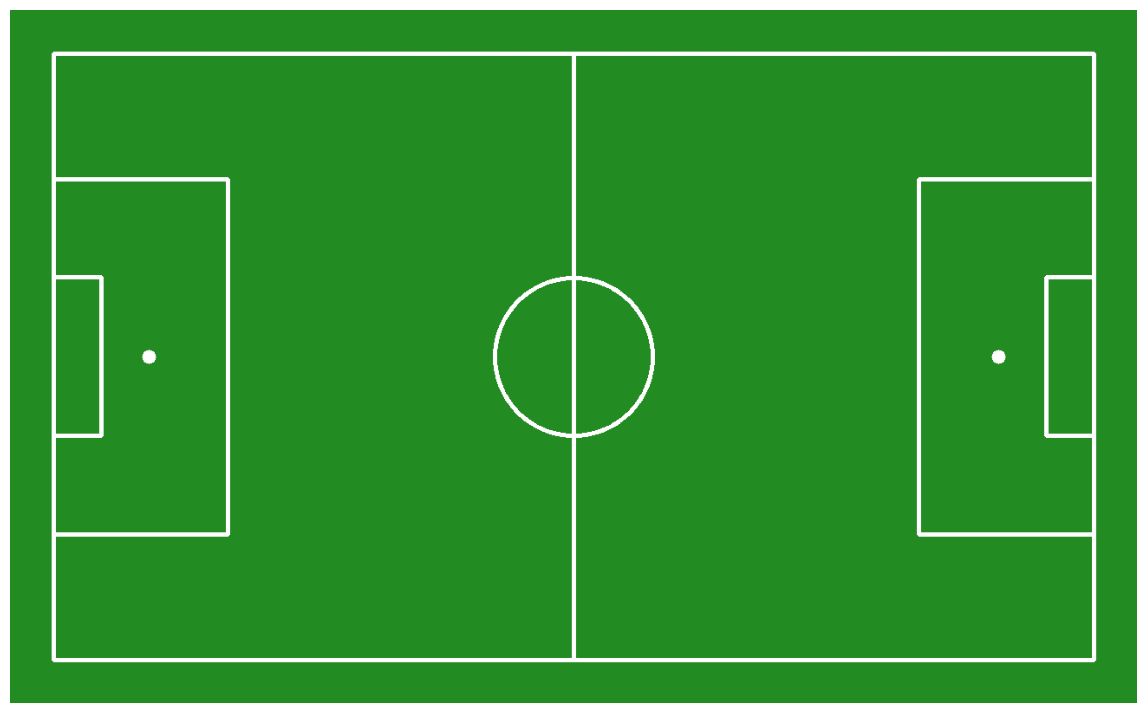

In [16]:
CONFIG = SoccerPitchConfiguration()
pitch_reference = draw_pitch(CONFIG)
sv.plot_image(pitch_reference, size=(16, 9))

vertex_annotator = sv.VertexAnnotator(color=sv.Color.from_hex('#FF1493'), radius=8)
vertex_annotator_2 = sv.VertexAnnotator(color=sv.Color.from_hex('#00BFFF'), radius=8)
edge_annotator = sv.EdgeAnnotator(
    color=sv.Color.from_hex('#00BFFF'),
    thickness=2,
    edges=CONFIG.edges
)

In [17]:
# 8. تطبيق التعليقات على الإطار
annotated_frame = frame.copy()

# رسم خطوط الملعب
if frame_all_points is not None:
    annotated_frame = edge_annotator.annotate(
        scene=annotated_frame,
        key_points=sv.KeyPoints(xy=frame_all_points[np.newaxis, ...])
    )

# رسم اللاعبين
if len(player_detections) > 0:
    annotated_frame = team_ellipse_annotator.annotate(
        scene=annotated_frame,
        detections=player_detections
    )
    
    player_labels = [f"#{track_id}" for track_id in player_detections.tracker_id]
    annotated_frame = team_label_annotator.annotate(
        scene=annotated_frame,
        detections=player_detections,
        labels=player_labels
    )

# رسم الحكام
if len(referee_detections) > 0:
    annotated_frame = referee_ellipse_annotator.annotate(
        scene=annotated_frame,
        detections=referee_detections
    )
    
    referee_labels = [f"#{track_id}" for track_id in referee_detections.tracker_id]
    annotated_frame = referee_label_annotator.annotate(
        scene=annotated_frame,
        detections=referee_detections,
        labels=referee_labels
    )

# رسم الكرة
if len(ball_detections) > 0:
    annotated_frame = triangle_annotator.annotate(
        scene=annotated_frame,
        detections=ball_detections
    )
    
    if ball_detections.tracker_id is not None:
        ball_labels = [f"#{track_id}" for track_id in ball_detections.tracker_id]
        ball_label_annotator = sv.LabelAnnotator(
            color=sv.ColorPalette([sv.Color.from_hex('#FFFF00')]),
            text_color=sv.Color.from_hex('#000000'),
            text_position=sv.Position.BOTTOM_CENTER
        )
        annotated_frame = ball_label_annotator.annotate(
            scene=annotated_frame,
            detections=ball_detections,
            labels=ball_labels
        )

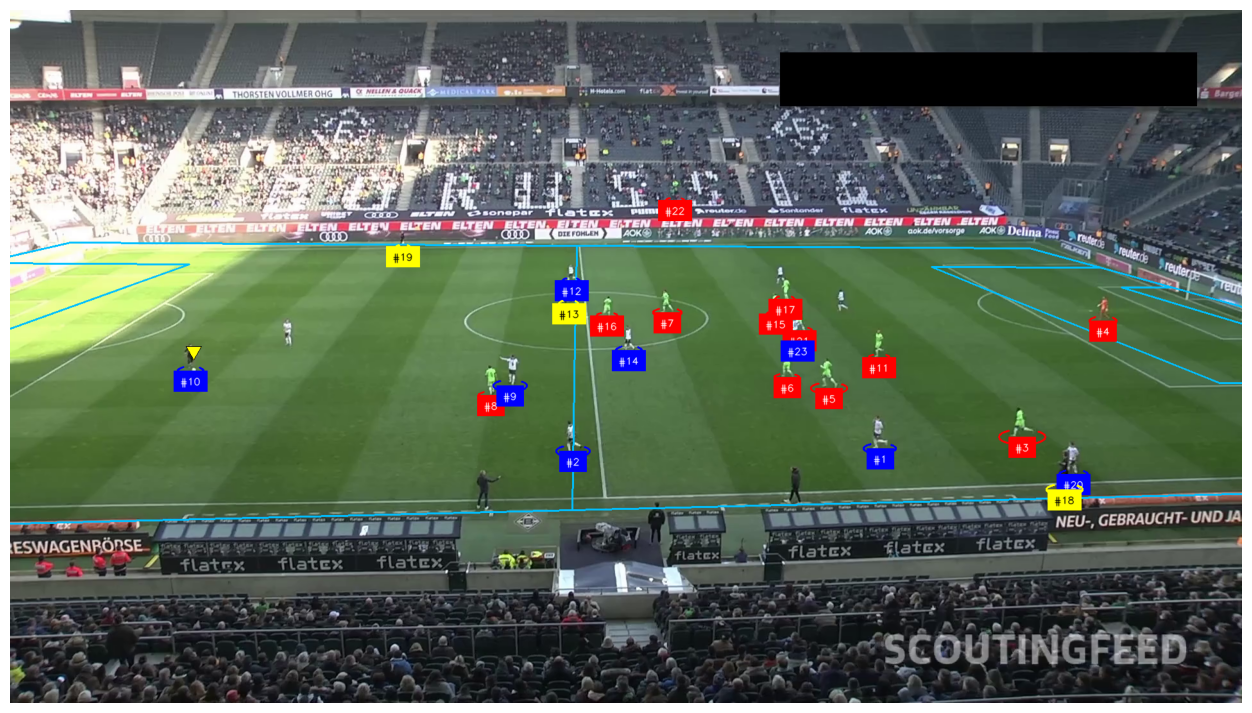

In [18]:
# 9. عرض النتيجة النهائية
sv.plot_image(annotated_frame, size=(16, 9))

In [19]:
cv2.imwrite('anotationframe.png', annotated_frame)  # لحفظها كـ PNG

True

## 🎥 قسم معالجة الفيديو (Video Processing)

**1. Imports and Dependencies**

In [20]:
import numpy as np
from ultralytics import YOLO
import cv2
import supervision as sv
from tqdm import tqdm
import torch
from transformers import AutoProcessor, SiglipVisionModel
import umap
from sklearn.cluster import KMeans
from typing import List, Dict, Optional
import requests
from sports.configs.soccer import SoccerPitchConfiguration

**2. Path and Model Initialization**

In [21]:
# Paths
SOURCE_VIDEO_PATH = '/kaggle/working/08fd33_0.mp4'
TARGET_VIDEO_PATH = '/kaggle/working/match_annotated.mp4'
PLAYER_MODEL_PATH = '/kaggle/input/final-models/detect_players.pt'
BALL_MODEL_PATH = '/kaggle/input/final-models/detect_ball.pt'
PITCH_MODEL_PATH = '/kaggle/input/final-models/pose_field.pt'
EVENT_MODEL_PATH = '/kaggle/input/final-models/yolo8m_trained_classify_SoccerNet.pt'

# Load models
print("Loading models...")
PLAYER_DETECTION_MODEL = YOLO(PLAYER_MODEL_PATH)
BALL_DETECTION_MODEL = YOLO(BALL_MODEL_PATH)
PITCH_DETECTION_MODEL = YOLO(PITCH_MODEL_PATH)
EVENT_CLASSIFICATION_MODEL = YOLO(EVENT_MODEL_PATH)  # Event classification model

Loading models...


**3. Constants and Configuration**

In [22]:
# Constants
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

# Event classes
EVENT_CLASSES = {
    0: 'Ball out of play',
    1: 'Foul',
    2: 'Goal',
    3: 'Offside',
    4: 'Shots off target',
    5: 'Shots on target'
}

**4. Team Classifier Implementation**

In [23]:
class TeamClassifier:
    def __init__(self, device="cuda"):
        self.device = device
        self.siglip_model_path = 'google/siglip-base-patch16-224'
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"TeamClassifier using device: {self.device}")
        self.embeddings_model = SiglipVisionModel.from_pretrained(self.siglip_model_path).to(self.device)
        self.embeddings_processor = AutoProcessor.from_pretrained(self.siglip_model_path)
        self.reducer = umap.UMAP(n_components=3)
        self.clustering_model = KMeans(n_clusters=2, n_init=10, random_state=42)

    def extract_embeddings(self, crops, batch_size=32):
        if not crops:
            return np.array([]).reshape(0, self.embeddings_model.config.hidden_size)
            
        crops_pil = [sv.cv2_to_pillow(crop) for crop in crops]
        from more_itertools import chunked
        batches = chunked(crops_pil, batch_size)

        data = []
        with torch.no_grad():
            for batch in batches:
                inputs = self.embeddings_processor(images=list(batch), return_tensors="pt").to(self.device)
                outputs = self.embeddings_model(**inputs)
                embeddings = outputs.pooler_output if outputs.pooler_output is not None else torch.mean(outputs.last_hidden_state, dim=1)
                data.append(embeddings.cpu().numpy())
        
        if not data:
             return np.array([]).reshape(0, self.embeddings_model.config.hidden_size)

        return np.concatenate(data)

    def fit(self, crops):
        if not crops:
            print("Warning: Trying to fit TeamClassifier with no crops.")
            return None
        embeddings = self.extract_embeddings(crops)
        if embeddings.shape[0] < self.clustering_model.n_clusters:
             print(f"Warning: Not enough samples ({embeddings.shape[0]}) to form {self.clustering_model.n_clusters} clusters. Skipping fit.")
             return None
        print(f"Fitting TeamClassifier with {embeddings.shape[0]} embeddings.")
        self.projections = self.reducer.fit_transform(embeddings)
        self.clusters = self.clustering_model.fit_predict(self.projections)
        print("TeamClassifier fit complete.")
        return self.clusters

    def predict(self, crops):
        if not crops:
             return np.array([], dtype=int)
        if not hasattr(self, 'reducer') or not hasattr(self.reducer, 'embedding_') or \
           not hasattr(self, 'clustering_model') or not hasattr(self.clustering_model, 'cluster_centers_'):
             print("Error: TeamClassifier predict called before fitting or fit failed.")
             return np.full(len(crops), -1, dtype=int)

        embeddings = self.extract_embeddings(crops)
        if embeddings.shape[0] == 0:
             return np.array([], dtype=int)
             
        projections = self.reducer.transform(embeddings)
        clusters = self.clustering_model.predict(projections)
        return clusters

**5. Player Crop Collection**

In [24]:
def collect_player_crops(source_video_path, player_id=PLAYER_ID, stride=30):
    try:
      video_info = sv.VideoInfo.from_video_path(source_video_path)
      total_frames = video_info.total_frames if video_info.total_frames is not None else 1
    except Exception as e:
        print(f"Could not get video info for {source_video_path}: {e}")
        total_frames = 1

    frame_generator = sv.get_video_frames_generator(source_path=source_video_path, stride=stride)
    crops = []
    estimated_iterations = total_frames // stride if total_frames > 0 else 0
    
    print(f"Collecting player crops from {source_video_path} with stride {stride}...")
    for frame in tqdm(frame_generator, total=estimated_iterations, desc='Collecting Player Crops'):
        result = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)
        detections = detections.with_nms(threshold=0.5, class_agnostic=True)
        players_detections = detections[detections.class_id == player_id]
        if len(players_detections) > 0:
            players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
            valid_crops = [crop for crop in players_crops if crop is not None and crop.shape[0] > 10 and crop.shape[1] > 10]
            crops.extend(valid_crops)
            
    print(f"Collected {len(crops)} player crops.")
    return crops

**6. Team Classifier Training**

In [25]:
print("Starting Team Classifier Training...")
player_crops = collect_player_crops(SOURCE_VIDEO_PATH, stride=60)
team_classifier = TeamClassifier(device="cuda" if torch.cuda.is_available() else "cpu")
if player_crops:
    team_classifier.fit(player_crops)
else:
    print("Could not collect player crops. Team classification might not work.")

Starting Team Classifier Training...


Collected 257 player crops.
TeamClassifier using device: cuda
Fitting TeamClassifier with 257 embeddings.
TeamClassifier fit complete.


**7. Pitch Configuration**

In [26]:
# Initialize pitch configuration
print("Initializing Pitch Configuration...")
CONFIG = SoccerPitchConfiguration()
pitch_width = 105  # meters
pitch_length = 68   # meters
goal_width = 7.32   # meters

# Define pitch regions
def get_pitch_region(x, y):
    """Determine pitch region based on normalized coordinates"""
    if x < 0.33 * pitch_width:
        return 'left'
    elif x > 0.66 * pitch_width:
        return 'right'
    else:
        return 'center'

# Define shot target areas
def is_shot_on_target(x, y):
    """Determine if shot is on target"""
    goal_x_min = (pitch_width - goal_width) / 2
    goal_x_max = (pitch_width + goal_width) / 2
    return (goal_x_min <= x <= goal_x_max) and (y <= 0.1 * pitch_length)

Initializing Pitch Configuration...


**8. View Transformer Initialization**

In [27]:
# Initialize transformer
transformer = None
frame_all_points = None

try:
    frame_generator_for_pitch = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, stride=1)
    first_frame = next(frame_generator_for_pitch)
    del frame_generator_for_pitch

    result = PITCH_DETECTION_MODEL.predict(first_frame, conf=0.3, verbose=False)[0]
    key_points = sv.KeyPoints.from_ultralytics(result)

    confidence_threshold = 0.5
    if key_points.xy.shape[1] > 0 and key_points.confidence.shape[1] > 0:
        filter_mask = key_points.confidence[0] > confidence_threshold
        frame_reference_points = key_points.xy[0][filter_mask]
        pitch_reference_points = np.array(CONFIG.vertices)[filter_mask]

        if len(frame_reference_points) >= 4:
            transformer = ViewTransformer(
                source=pitch_reference_points,
                target=frame_reference_points
            )
            pitch_all_points = np.array(CONFIG.vertices)
            frame_all_points = transformer.transform_points(points=pitch_all_points)
            print("Pitch homography calculated successfully.")
        else:
            print("Warning: Not enough high-confidence pitch keypoints found in the first frame. Pitch lines will not be drawn.")
    else:
        print("Warning: No pitch keypoints detected in the first frame. Pitch lines will not be drawn.")

except StopIteration:
    print("Error: Could not read the first frame to calculate pitch homography.")
except Exception as e:
    print(f"An error occurred during pitch homography calculation: {e}")

Pitch homography calculated successfully.


**9. Annotators Initialization**

In [28]:
print("Initializing Annotators...")
team_colors = {
    0: sv.Color.from_hex('#FF0000'),  # Red
    1: sv.Color.from_hex('#0000FF')   # Blue
}
default_player_color = sv.Color.from_hex('#808080') # Gray

# Drawing annotators
team_ellipse_annotator = sv.EllipseAnnotator(thickness=2)
team_label_annotator = sv.LabelAnnotator(text_color=sv.Color.WHITE, text_position=sv.Position.BOTTOM_CENTER)
referee_color = sv.Color.YELLOW
referee_ellipse_annotator = sv.EllipseAnnotator(color=sv.Color.YELLOW, thickness=2)
referee_label_annotator = sv.LabelAnnotator(color=sv.Color.YELLOW, text_color=sv.Color.BLACK, text_position=sv.Position.BOTTOM_CENTER)
ball_color = sv.Color.YELLOW
ball_triangle_annotator = sv.TriangleAnnotator(color=sv.Color.YELLOW, base=25, height=21, outline_thickness=1)
ball_label_annotator = sv.LabelAnnotator(color=sv.Color.YELLOW, text_color=sv.Color.BLACK, text_position=sv.Position.BOTTOM_CENTER)
pitch_point_annotator = sv.VertexAnnotator(color=sv.Color.GREEN, radius=5)

Initializing Annotators...


**10. Match Statistics Setup**

In [29]:
# Match statistics
possession_counts = {0: 0, 1: 0, 'neutral': 0}
total_processed_frames_for_possession = 0

shot_counters = {
    0: {'total': 0, 'on_target': 0, 'off_target': 0},
    1: {'total': 0, 'on_target': 0, 'off_target': 0}
}

attempt_counters = {
    0: {'successful': 0, 'failed': 0},
    1: {'successful': 0, 'failed': 0}
}

pitch_region_counters = {
    0: {'left': 0, 'center': 0, 'right': 0},
    1: {'left': 0, 'center': 0, 'right': 0}
}

# Enhanced pass statistics
pass_counters = {
    0: {'correct': 0, 'incorrect': 0, 'total_distance': 0, 'count': 0},
    1: {'correct': 0, 'incorrect': 0, 'total_distance': 0, 'count': 0}
}

# Pass tracking variables
pass_tracking = {
    'last_team': None,
    'last_player_id': None,
    'last_player_pos': None,
    'last_ball_pos': None,
    'frames_since_last_pass': 0,
    'min_pass_frames': 10,  # Minimum frames between passes
    'max_pass_frames': 60,  # Maximum frames to recognize a pass
    'pass_distance_threshold': 50,  # Minimum pass distance (pixels)
    'max_pass_distance': 500  # Maximum pass distance (pixels)
}

# Event statistics
event_counters = {
    0: {event: 0 for event in EVENT_CLASSES.values()},  # Team 0
    1: {event: 0 for event in EVENT_CLASSES.values()}   # Team 1
}

last_player_in_possession_info = {'tracker_id': None, 'team_id': None, 'position': None}
last_ball_position = None
ball_speed_threshold = 15  # Ball speed required to consider it a shot (pixels/frame)
pass_distance_threshold = 300  # Maximum pass distance (pixels)
min_pass_frames = 5  # Minimum frames between pass and receive

player_ellipse_annotator = sv.EllipseAnnotator(thickness=2)
player_label_annotator = sv.LabelAnnotator(text_color=sv.Color.WHITE, text_position=sv.Position.BOTTOM_CENTER, text_scale=0.5, text_thickness=1)
referee_ellipse_annotator = sv.EllipseAnnotator(color=referee_color, thickness=2)
referee_label_annotator = sv.LabelAnnotator(color=referee_color, text_color=sv.Color.BLACK, text_position=sv.Position.BOTTOM_CENTER, text_scale=0.5)
ball_triangle_annotator = sv.TriangleAnnotator(color=ball_color, base=25, height=21, outline_thickness=1)
ball_label_annotator = sv.LabelAnnotator(color=ball_color, text_color=sv.Color.BLACK, text_position=sv.Position.BOTTOM_CENTER, text_scale=0.5)

**11. Event Classification Function**

In [30]:
def classify_events(frame, team_id, confidence_threshold=0.98):
    results = EVENT_CLASSIFICATION_MODEL.predict(frame, conf=confidence_threshold, verbose=False)
    detected_events = []
    
    for result in results:
        if result.boxes is not None and len(result.boxes) > 0:
            for box, conf, cls in zip(result.boxes.xyxy, result.boxes.conf, result.boxes.cls):
                if conf >= confidence_threshold:
                    event_name = EVENT_CLASSES.get(int(cls), 'Unknown')
                    detected_events.append(event_name)
    
    # Update counter if any event detected
    if detected_events and team_id in [0, 1]:
        for event in detected_events:
            event_counters[team_id][event] += 1
    
    return detected_events

**12. Possession Bar Drawing**

In [31]:
def draw_possession_bar(frame, possession_team_0_percent, possession_team_1_percent, 
                       bar_width=300, bar_height=30, margin=10):
    frame_height, frame_width, _ = frame.shape
    bar_x_start = (frame_width - bar_width) // 2
    bar_y_start = margin

    team_0_width = int(bar_width * (possession_team_0_percent / 100))
    team_1_width = bar_width - team_0_width

    cv2.rectangle(
        frame,
        (bar_x_start, bar_y_start),
        (bar_x_start + team_0_width, bar_y_start + bar_height),
        team_colors[0].as_bgr(),
        cv2.FILLED
    )

    cv2.rectangle(
        frame,
        (bar_x_start + team_0_width, bar_y_start),
        (bar_x_start + bar_width, bar_y_start + bar_height),
        team_colors[1].as_bgr(),
        cv2.FILLED
    )

    text = f"{possession_team_0_percent:.1f}% | {possession_team_1_percent:.1f}%"
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.7
    font_thickness = 2
    text_size, _ = cv2.getTextSize(text, font, font_scale, font_thickness)
    text_x = (frame_width - text_size[0]) // 2
    text_y = bar_y_start + bar_height + text_size[1] + 5

    cv2.putText(frame, text, (text_x + 1, text_y + 1), font, font_scale, (0, 0, 0), font_thickness + 1, cv2.LINE_AA)
    cv2.putText(frame, text, (text_x, text_y), font, font_scale, (255, 255, 255), font_thickness, cv2.LINE_AA)

    return frame

**13. Tactical Lines Drawing**

In [32]:
def draw_team_tactical_lines(frame, detections, team_ids, team_color, pitch_points, transformer):
    if len(detections) < 2 or transformer is None:
        return frame
    
    # Filter players for the specified team
    team_mask = (team_ids == 0) if team_color == team_colors[0] else (team_ids == 1)
    team_detections = detections[team_mask]
    
    if len(team_detections) < 2:
        return frame
    
    # Get player centers in natural pitch coordinates
    centers = team_detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
    pitch_positions = transformer.transform_points(centers)
    
    # Calculate player density in each third of the pitch
    thirds_count = [0, 0, 0]
    for (x, y) in pitch_positions:
        if y > 0.66 * pitch_length:  # Back third
            thirds_count[0] += 1
        elif y < 0.33 * pitch_length:  # Front third
            thirds_count[2] += 1
        else:  # Middle third
            thirds_count[1] += 1
    
    # Special case: if most players are in one third (more than 60%)
    dominant_third = None
    total_players = len(team_detections)
    if max(thirds_count) / total_players > 0.6:
        dominant_third = np.argmax(thirds_count)
    
    if dominant_third is not None:
        # Case of clustering in one third - use different algorithm
        return draw_compressed_formation(frame, team_detections, centers, pitch_positions, team_color, dominant_third)
    else:
        # Normal case - distribution across all thirds
        return draw_normal_formation(frame, team_detections, centers, pitch_positions, team_color)

def draw_normal_formation(frame, detections, centers, pitch_positions, team_color):
    # Normal classification of players into thirds
    defenders = []
    midfielders = []
    attackers = []
    
    for i, (x, y) in enumerate(pitch_positions):
        if y > 0.66 * pitch_length:  # Defenders
            defenders.append((i, x, y))
        elif y < 0.33 * pitch_length:  # Attackers
            attackers.append((i, x, y))
        else:  # Midfielders
            midfielders.append((i, x, y))
    
    # Connect players in each line (as before)
    connect_players_in_line(frame, defenders, centers, team_color)
    connect_players_in_line(frame, midfielders, centers, team_color)
    connect_players_in_line(frame, attackers, centers, team_color)
    
    # Connections between lines
    connect_lines(frame, defenders, midfielders, centers, team_color)
    connect_lines(frame, midfielders, attackers, centers, team_color)
    
    return frame

def draw_compressed_formation(frame, detections, centers, pitch_positions, team_color, dominant_third):
    # Special algorithm for clustering in one third
    players = [(i, x, y) for i, (x, y) in enumerate(pitch_positions)]
    
    # 1. Split players into small groups by horizontal positions
    sorted_players = sorted(players, key=lambda p: p[1])  # Sort by X axis
    groups = []
    current_group = [sorted_players[0]]
    
    for player in sorted_players[1:]:
        if abs(player[1] - current_group[-1][1]) < 0.15 * pitch_width:  # Group close horizontally
            current_group.append(player)
        else:
            groups.append(current_group)
            current_group = [player]
    groups.append(current_group)
    
    # 2. Connect players within each group
    for group in groups:
        if len(group) > 1:
            # Connect each player to nearest players in group
            for i in range(len(group)):
                for j in range(i+1, len(group)):
                    if distance(group[i], group[j]) < 0.25 * pitch_width:
                        cv2.line(frame, 
                                tuple(map(int, centers[group[i][0]])), 
                                tuple(map(int, centers[group[j][0]])),
                                team_color.as_bgr(), 2, cv2.LINE_AA)
    
    # 3. Connect nearby groups
    if len(groups) > 1:
        for i in range(len(groups)-1):
            # Find closest player between groups
            min_dist = float('inf')
            pair = None
            
            for p1 in groups[i]:
                for p2 in groups[i+1]:
                    dist = distance(p1, p2)
                    if dist < min_dist:
                        min_dist = dist
                        pair = (p1, p2)
            
            if min_dist < 0.3 * pitch_width:
                cv2.line(frame,
                        tuple(map(int, centers[pair[0][0]])),
                        tuple(map(int, centers[pair[1][0]])),
                        team_color.as_bgr(), 1, cv2.LINE_AA)
    
    # 4. Identify and connect central players (if any)
    if len(players) >= 3:
        center_players = sorted(players, key=lambda p: abs(p[1] - pitch_width/2))[:3]
        for i in range(len(center_players)):
            for j in range(i+1, len(center_players)):
                cv2.line(frame,
                        tuple(map(int, centers[center_players[i][0]])),
                        tuple(map(int, centers[center_players[j][0]])),
                        team_color.as_bgr(), 2, cv2.LINE_AA)
    
    return frame

def distance(p1, p2):
    return np.sqrt((p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

def connect_players_in_line(frame, players, centers, team_color, max_connections=2):
    if len(players) < 2:
        return
    
    players_array = np.array([(x, y) for (idx, x, y) in players])
    dist_matrix = np.linalg.norm(players_array[:, np.newaxis] - players_array, axis=2)
    
    connections = set()
    for i in range(len(players)):
        closest_indices = np.argsort(dist_matrix[i])[1:max_connections+1]
        for j in closest_indices:
            if dist_matrix[i][j] < 0.3 * pitch_width:
                connection = tuple(sorted((players[i][0], players[j][0])))
                connections.add(connection)
    
    for (i, j) in connections:
        cv2.line(frame, 
                tuple(map(int, centers[i])), 
                tuple(map(int, centers[j])),
                team_color.as_bgr(), 2, cv2.LINE_AA)

def connect_lines(frame, line1, line2, centers, team_color):
    if not line1 or not line2:
        return
    
    line1_array = np.array([(x, y) for (idx, x, y) in line1])
    line2_array = np.array([(x, y) for (idx, x, y) in line2])
    
    for i, (idx1, x1, y1) in enumerate(line1):
        distances = np.linalg.norm(line2_array - np.array([x1, y1]), axis=1)
        closest_idx = np.argmin(distances)
        if distances[closest_idx] < 0.4 * pitch_width:
            cv2.line(frame,
                    tuple(map(int, centers[idx1])),
                    tuple(map(int, centers[line2[closest_idx][0]])),
                    team_color.as_bgr(), 1, cv2.LINE_AA)

**14. Ball Speed Calculation**

In [33]:
def calculate_ball_speed(current_position, last_position, fps):
    if last_position is None or current_position is None:
        return 0
    distance = np.linalg.norm(current_position - last_position)
    return distance * fps  # pixels/second

**15. Video Processing Setup**

In [34]:
print("Starting Video Processing...")
try:
    video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
    print(f"Video Info: {video_info.width}x{video_info.height}, {video_info.fps} FPS, Total Frames: {video_info.total_frames}")
    
    # First 30 minutes (1800 seconds)
    max_frames = 1800 * video_info.fps if video_info.fps > 0 else 1800 * 25
except Exception as e:
    print(f"Could not get video info for {SOURCE_VIDEO_PATH}: {e}")
    video_info = sv.VideoInfo(width=1920, height=1080, fps=25)
    max_frames = 1800 * 25
    print(f"Using default video info: {video_info.width}x{video_info.height}, {video_info.fps} FPS")

byte_tracker = sv.ByteTrack(frame_rate=video_info.fps if video_info.fps > 0 else 30)

# Initialize pitch annotators
pitch_line_color = sv.Color.GREEN
pitch_point_color = sv.Color.RED
pitch_edge_annotator = sv.EdgeAnnotator(color=pitch_line_color, thickness=2, edges=CONFIG.edges)
pitch_point_annotator = sv.VertexAnnotator(color=pitch_point_color, radius=4)

Starting Video Processing...
Video Info: 1920x1080, 25 FPS, Total Frames: 750


**15. Main Video Processing Loop**

In [35]:
try:
    frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)
    total_f = min(video_info.total_frames, max_frames) if video_info.total_frames is not None else max_frames
    
    with sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info) as sink:
        for frame_count, frame in enumerate(tqdm(frame_generator, total=total_f, desc=f"Processing Video")):
            if frame_count >= max_frames:
                break
                
            total_processed_frames_for_possession += 1
            annotated_frame = frame.copy()

            # Pitch detection
            current_frame_all_points_transformed = None
            if PITCH_DETECTION_MODEL is not None:
                try:
                    result_pitch = PITCH_DETECTION_MODEL.predict(annotated_frame, conf=0.3, verbose=False)[0]
                    key_points_pitch = sv.KeyPoints.from_ultralytics(result_pitch)
                    
                    if key_points_pitch.xy is not None and key_points_pitch.xy.shape[1] > 0 and \
                       key_points_pitch.confidence is not None and key_points_pitch.confidence.shape[1] > 0:

                        if key_points_pitch.xy.shape[1] == len(pitch_all_points):
                            filter_mask = key_points_pitch.confidence[0] > 0.5
                            current_frame_reference_points = key_points_pitch.xy[0][filter_mask]
                            pitch_reference_points_for_transform = pitch_all_points[filter_mask]

                            if len(current_frame_reference_points) >= 4:
                                current_transformer = ViewTransformer(
                                    source=pitch_reference_points_for_transform,
                                    target=current_frame_reference_points
                                )
                                temp_transformed = current_transformer.transform_points(points=pitch_all_points)
                                if temp_transformed is not None and np.all(np.isfinite(temp_transformed)):
                                    current_frame_all_points_transformed = temp_transformed
                except Exception as e_pitch:
                    if frame_count % 120 == 0: 
                        print(f"Error processing pitch in frame {frame_count}: {e_pitch}")

            # Player and ball detection
            player_result = PLAYER_DETECTION_MODEL.predict(annotated_frame, conf=0.3, iou=0.5, verbose=False)[0]
            player_detections = sv.Detections.from_ultralytics(player_result)
            ball_result = BALL_DETECTION_MODEL.predict(annotated_frame, conf=0.3, iou=0.3, verbose=False)[0]
            ball_detections = sv.Detections.from_ultralytics(ball_result)
            
            if len(ball_detections) > 0 and (ball_detections.class_id is None or len(ball_detections.class_id) == 0):
                ball_detections.class_id = np.full(len(ball_detections), BALL_ID)

            # Object tracking
            all_detections_list = []
            if len(player_detections) > 0: 
                all_detections_list.append(player_detections)
            if len(ball_detections) > 0: 
                all_detections_list.append(ball_detections)

            if all_detections_list:
                combined_detections = sv.Detections.merge(detections_list=all_detections_list).with_nms(threshold=0.5)
                tracked_detections = byte_tracker.update_with_detections(detections=combined_detections)
            else:
                tracked_detections = byte_tracker.update_with_detections(detections=sv.Detections.empty())

            # Separate detections
            players_mask = np.isin(tracked_detections.class_id, [PLAYER_ID, GOALKEEPER_ID])
            referee_mask = tracked_detections.class_id == REFEREE_ID
            ball_mask = tracked_detections.class_id == BALL_ID

            player_tracked_detections = tracked_detections[players_mask]
            referee_tracked_detections = tracked_detections[referee_mask]
            ball_tracked_detections = tracked_detections[ball_mask]

            # Team classification
            player_team_ids = np.full(len(player_tracked_detections), -1, dtype=int)
            if len(player_tracked_detections) > 0 and team_classifier is not None:
                player_crops = []
                valid_indices_for_classification = []
                
                for i, xyxy in enumerate(player_tracked_detections.xyxy):
                    crop = sv.crop_image(annotated_frame, xyxy)
                    if crop is not None and crop.shape[0] > 10 and crop.shape[1] > 10:
                        player_crops.append(crop)
                        valid_indices_for_classification.append(i)

                if player_crops:
                    try:
                        predicted_teams = team_classifier.predict(player_crops)
                        for idx, team_id in zip(valid_indices_for_classification, predicted_teams):
                            if team_id != -1:
                                player_team_ids[idx] = team_id
                    except Exception as e_classify:
                        if frame_count % 120 == 0: 
                            print(f"Error during team classification in frame {frame_count}: {e_classify}")

            # Event classification
            current_team_with_possession = None
            current_player_position = None
            
            if len(ball_tracked_detections) == 1 and ball_tracked_detections.tracker_id is not None:
                try:
                    ball_center = ball_tracked_detections.get_anchors_coordinates(anchor=sv.Position.CENTER)[0]
                    valid_players_mask = np.isin(player_team_ids, [0, 1]) & (player_tracked_detections.tracker_id != None)
                    valid_player_detections = player_tracked_detections[valid_players_mask]
                    valid_player_team_ids = player_team_ids[valid_players_mask]

                    if len(valid_player_detections) > 0:
                        player_anchors = valid_player_detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
                        distances = np.linalg.norm(player_anchors - ball_center, axis=1)
                        min_distance_idx = np.argmin(distances)
                        distance_threshold = 150  # pixels

                        if distances[min_distance_idx] < distance_threshold:
                            closest_team_id = int(valid_player_team_ids[min_distance_idx])
                            current_team_with_possession = closest_team_id
                            current_player_position = player_anchors[min_distance_idx]
                            
                            # Classify events for team with possession
                            detected_events = classify_events(annotated_frame, closest_team_id)
                            if detected_events and frame_count % 30 == 0:  # Print events every 30 frames to avoid repetition
                                print(f"Frame {frame_count}: Team {closest_team_id} events: {detected_events}")
                except Exception as e_event:
                    if frame_count % 120 == 0: 
                        print(f"Frame {frame_count}: Error during event classification: {e_event}")

            # Possession calculation
            current_player_info = {'tracker_id': None, 'team_id': None, 'position': None}
            current_frame_possessor_team = 'neutral'

            if current_team_with_possession is not None:
                current_player_info['team_id'] = current_team_with_possession
                current_player_info['position'] = current_player_position
                current_frame_possessor_team = current_team_with_possession

            if current_frame_possessor_team in possession_counts:
                possession_counts[current_frame_possessor_team] += 1
            else:
                possession_counts['neutral'] += 1

            # Shot and attempt statistics
            if len(ball_tracked_detections) == 1 and transformer is not None:
                try:
                    ball_center = ball_tracked_detections.get_anchors_coordinates(anchor=sv.Position.CENTER)[0]
                    ball_on_pitch = transformer.transform_points(np.array([ball_center]))[0]
                    current_ball_speed = calculate_ball_speed(ball_center, last_ball_position, video_info.fps)
                    
                    if current_player_info['team_id'] in [0, 1]:
                        team_id = current_player_info['team_id']
                        x_norm = ball_on_pitch[0] / pitch_width
                        
                        # Update region activity
                        region = get_pitch_region(ball_on_pitch[0], ball_on_pitch[1])
                        pitch_region_counters[team_id][region] += 1
                        
                        # Detect shots only when ball is moving fast
                        if current_ball_speed > ball_speed_threshold:
                            # Ensure ball is moving away from player
                            if last_player_in_possession_info['position'] is not None:
                                distance_from_last_player = np.linalg.norm(ball_center - last_player_in_possession_info['position'])
                                if distance_from_last_player > 50:  # Ball is away from player
                                    shot_counters[team_id]['total'] += 1
                                    
                                    if is_shot_on_target(ball_on_pitch[0], ball_on_pitch[1]):
                                        shot_counters[team_id]['on_target'] += 1
                                    else:
                                        shot_counters[team_id]['off_target'] += 1
                        
                except Exception as e_stats:
                    if frame_count % 120 == 0: 
                        print(f"Frame {frame_count}: Error during stats calculation: {e_stats}")

            # Update pass information
            if (current_player_info['tracker_id'] is not None and 
                last_player_in_possession_info['tracker_id'] is not None and
                current_player_info['tracker_id'] != last_player_in_possession_info['tracker_id'] and
                current_player_info['position'] is not None and 
                last_player_in_possession_info['position'] is not None):
                
                passer_team = last_player_in_possession_info['team_id']
                receiver_team = current_player_info['team_id']
                distance_between_players = np.linalg.norm(current_player_info['position'] - last_player_in_possession_info['position'])
                
                # Only if distance between players is reasonable
                if distance_between_players < pass_distance_threshold:
                    if passer_team in [0, 1] and receiver_team in [0, 1]:
                        if passer_team == receiver_team:
                            pass_counters[passer_team]['correct'] += 1
                        else:
                            pass_counters[passer_team]['incorrect'] += 1

            if current_player_info['tracker_id'] is not None:
                last_player_in_possession_info = current_player_info.copy()
                
            if len(ball_tracked_detections) == 1:
                current_ball_pos = ball_tracked_detections.get_anchors_coordinates(anchor=sv.Position.CENTER)[0]
                
                # If there's a change in team possession
                if current_team_with_possession is not None and pass_tracking['last_team'] is not None:
                    pass_tracking['frames_since_last_pass'] += 1
                    
                    # Conditions for considering it a pass:
                    # 1. Current team is same as last team (successful pass)
                    # 2. Or teams are different (failed pass/interception)
                    # 3. Ball has moved enough distance
                    # 4. Time since last pass is reasonable
                    
                    ball_moved_distance = np.linalg.norm(current_ball_pos - pass_tracking['last_ball_pos']) if pass_tracking['last_ball_pos'] is not None else 0
                    
                    if (pass_tracking['frames_since_last_pass'] >= pass_tracking['min_pass_frames'] and 
                        pass_tracking['frames_since_last_pass'] <= pass_tracking['max_pass_frames'] and
                        ball_moved_distance >= pass_tracking['pass_distance_threshold'] and
                        ball_moved_distance <= pass_tracking['max_pass_distance']):
                        
                        # Calculate distance between players
                        player_distance = np.linalg.norm(current_player_position - pass_tracking['last_player_pos']) if current_player_position is not None and pass_tracking['last_player_pos'] is not None else 0
                        
                        if current_team_with_possession == pass_tracking['last_team']:
                            # Successful pass between same team players
                            pass_counters[current_team_with_possession]['correct'] += 1
                            pass_counters[current_team_with_possession]['total_distance'] += player_distance
                            pass_counters[current_team_with_possession]['count'] += 1
                            print(f"Frame {frame_count}: Successful pass for team {current_team_with_possession}, distance: {player_distance:.1f} pixels")
                        else:
                            # Failed pass (intercepted by other team)
                            pass_counters[pass_tracking['last_team']]['incorrect'] += 1
                            print(f"Frame {frame_count}: Intercepted pass from team {pass_tracking['last_team']} to team {current_team_with_possession}")
                
                # Update last pass information
                if current_team_with_possession is not None:
                    pass_tracking['last_team'] = current_team_with_possession
                    pass_tracking['last_player_id'] = current_player_info['tracker_id']
                    pass_tracking['last_player_pos'] = current_player_position
                    pass_tracking['last_ball_pos'] = current_ball_pos
                    pass_tracking['frames_since_last_pass'] = 0
            else:
                pass_tracking['frames_since_last_pass'] += 1
                
                # If too much time passes without a pass, reset tracking
                if pass_tracking['frames_since_last_pass'] > pass_tracking['max_pass_frames']:
                    pass_tracking['last_team'] = None
                    pass_tracking['last_player_id'] = None
                    pass_tracking['last_player_pos'] = None
                    pass_tracking['last_ball_pos'] = None


            # Draw pitch
            if current_frame_all_points_transformed is not None:
                try:
                    current_frame_pitch_keypoints = sv.KeyPoints(xy=current_frame_all_points_transformed[np.newaxis, ...])
                    annotated_frame = pitch_edge_annotator.annotate(scene=annotated_frame, key_points=current_frame_pitch_keypoints)
                    annotated_frame = pitch_point_annotator.annotate(scene=annotated_frame, key_points=current_frame_pitch_keypoints)
                except Exception as e_draw:
                    if frame_count % 120 == 0: 
                        print(f"Frame {frame_count}: Error drawing pitch: {e_draw}")

            # Draw players
            if len(player_tracked_detections) > 0:
                player_labels = []
                if player_tracked_detections.tracker_id is not None:
                    for i in range(len(player_tracked_detections)):
                        current_tracker_id = player_tracked_detections.tracker_id[i]
                        player_labels.append(f"#{current_tracker_id}")
                else:
                    player_labels = ["?"] * len(player_tracked_detections)

                colors_for_players = [team_colors.get(tid, default_player_color) for tid in player_team_ids]

                for i in range(len(player_tracked_detections)):
                    detection_single = player_tracked_detections[i:i+1]
                    color_single = colors_for_players[i]
                    label_single = player_labels[i]

                    player_ellipse_annotator.color = color_single
                    player_label_annotator.color = color_single

                    annotated_frame = player_ellipse_annotator.annotate(
                        scene=annotated_frame,
                        detections=detection_single
                    )
                    annotated_frame = player_label_annotator.annotate(
                        scene=annotated_frame,
                        detections=detection_single,
                        labels=[label_single]
                    )

            # Draw referees
            if len(referee_tracked_detections) > 0:
                annotated_frame = referee_ellipse_annotator.annotate(scene=annotated_frame, detections=referee_tracked_detections)
                referee_labels = []
                if referee_tracked_detections.tracker_id is not None:
                    referee_labels = [f"REF #{track_id}" for track_id in referee_tracked_detections.tracker_id]
                else:
                    referee_labels = ["REF"] * len(referee_tracked_detections)
                annotated_frame = referee_label_annotator.annotate(scene=annotated_frame, detections=referee_tracked_detections, labels=referee_labels)

            # Draw ball
            if len(ball_tracked_detections) > 0:
                annotated_frame = ball_triangle_annotator.annotate(scene=annotated_frame, detections=ball_tracked_detections)
                ball_labels = []
                if ball_tracked_detections.tracker_id is not None:
                    ball_labels = [f"B #{track_id}" for track_id in ball_tracked_detections.tracker_id]
                else:
                    ball_labels = ["BALL"] * len(ball_tracked_detections)
                annotated_frame = ball_label_annotator.annotate(scene=annotated_frame, detections=ball_tracked_detections, labels=ball_labels)

            # Draw tactical lines for each team
            # if current_frame_all_points_transformed is not None:
            #     annotated_frame = draw_team_tactical_lines(
            #         annotated_frame, 
            #         player_tracked_detections, 
            #         np.array(player_team_ids), 
            #         team_colors[0], 
            #         current_frame_all_points_transformed,
            #         transformer
            #         )
            #     annotated_frame = draw_team_tactical_lines(
            #         annotated_frame, 
            #         player_tracked_detections, 
            #         np.array(player_team_ids), 
            #         team_colors[1], 
            #         current_frame_all_points_transformed,
            #         transformer
            #         )

            # Draw possession bar
            total_possession_frames = possession_counts[0] + possession_counts[1]
            if total_possession_frames > 0:
                team_0_perc = (possession_counts[0] / total_possession_frames) * 100
                team_1_perc = (possession_counts[1] / total_possession_frames) * 100
            else:
                team_0_perc, team_1_perc = 0.0, 0.0

            annotated_frame = draw_possession_bar(
                annotated_frame, team_0_perc, team_1_perc,
                bar_width=300, bar_height=25, margin=10
            )

            # Display statistics on video
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.6
            font_thickness = 1
            text_color = (255, 255, 255)
            text_bg_color = (0, 0, 0)
            line_spacing = 30
            start_y = 70
            
            # Team 0 (Red)
            team0_stats = [
                f"Team 0: S {shot_counters[0]['on_target']}/{shot_counters[0]['total']}",
                f"Pass: {pass_counters[0]['correct']}/{pass_counters[0]['correct']+pass_counters[0]['incorrect']}",
                f"Areas: L{pitch_region_counters[0]['left']} C{pitch_region_counters[0]['center']} R{pitch_region_counters[0]['right']}"
            ]
            
            for i, stat in enumerate(team0_stats):
                cv2.putText(annotated_frame, stat, 
                           (20, start_y + i * line_spacing), 
                           font, font_scale, team_colors[0].as_bgr(), font_thickness + 1, cv2.LINE_AA)
                cv2.putText(annotated_frame, stat, 
                           (19, start_y + i * line_spacing - 1), 
                           font, font_scale, text_color, font_thickness, cv2.LINE_AA)
            
            # Team 1 (Blue)
            team1_stats = [
                f"Team 1: S {shot_counters[1]['on_target']}/{shot_counters[1]['total']}",
                f"Pass: {pass_counters[1]['correct']}/{pass_counters[1]['correct']+pass_counters[1]['incorrect']}",
                f"Areas: L{pitch_region_counters[1]['left']} C{pitch_region_counters[1]['center']} R{pitch_region_counters[1]['right']}"
            ]
            
            for i, stat in enumerate(team1_stats):
                text_size = cv2.getTextSize(stat, font, font_scale, font_thickness)[0]
                text_x = annotated_frame.shape[1] - text_size[0] - 20
                
                cv2.putText(annotated_frame, stat, 
                           (text_x, start_y + i * line_spacing), 
                           font, font_scale, team_colors[1].as_bgr(), font_thickness + 1, cv2.LINE_AA)
                cv2.putText(annotated_frame, stat, 
                           (text_x - 1, start_y + i * line_spacing - 1), 
                           font, font_scale, text_color, font_thickness, cv2.LINE_AA)

            # Display event statistics in yellow at bottom
            event_font_scale = 0.5
            event_line_spacing = 25
            event_start_y = annotated_frame.shape[0] - 100
            
            # Team 0 (Red)
            team0_events = [
                f"Team 0 Events:",
                f"Out: {event_counters[0]['Ball out of play']}  Foul: {event_counters[0]['Foul']}",
                f"Goal: {event_counters[0]['Goal']}  Offside: {event_counters[0]['Offside']}",
                f"Shots: {event_counters[0]['Shots off target']}/{event_counters[0]['Shots on target']}"
            ]
            
            for i, stat in enumerate(team0_events):
                cv2.putText(annotated_frame, stat, 
                           (20, event_start_y + i * event_line_spacing), 
                           font, event_font_scale, (0, 255, 255), font_thickness + 1, cv2.LINE_AA)
                cv2.putText(annotated_frame, stat, 
                           (19, event_start_y + i * event_line_spacing - 1), 
                           font, event_font_scale, (0, 0, 0), font_thickness, cv2.LINE_AA)
            
            # Team 1 (Blue)
            team1_events = [
                f"Team 1 Events:",
                f"Out: {event_counters[1]['Ball out of play']}  Foul: {event_counters[1]['Foul']}",
                f"Goal: {event_counters[1]['Goal']}  Offside: {event_counters[1]['Offside']}",
                f"Shots: {event_counters[1]['Shots off target']}/{event_counters[1]['Shots on target']}"
            ]
            
            for i, stat in enumerate(team1_events):
                text_size = cv2.getTextSize(stat, font, event_font_scale, font_thickness)[0]
                text_x = annotated_frame.shape[1] - text_size[0] - 20
                
                cv2.putText(annotated_frame, stat, 
                           (text_x, event_start_y + i * event_line_spacing), 
                           font, event_font_scale, (0, 255, 255), font_thickness + 1, cv2.LINE_AA)
                cv2.putText(annotated_frame, stat, 
                           (text_x - 1, event_start_y + i * event_line_spacing - 1), 
                           font, event_font_scale, (0, 0, 0), font_thickness, cv2.LINE_AA)

            # Save frame
            sink.write_frame(frame=annotated_frame)

except Exception as e:
    print(f"\n--- An error occurred during video processing ---")
    import traceback
    traceback.print_exc()
    print("Processing stopped prematurely.")

Processing Video:  19%|█▉        | 144/750 [00:53<03:44,  2.70it/s]

Frame 143: Successful pass for team 0, distance: 195.7 pixels


Processing Video:  27%|██▋       | 201/750 [01:15<03:22,  2.71it/s]

Frame 200: Successful pass for team 0, distance: 232.7 pixels


Processing Video:  39%|███▉      | 294/750 [01:49<02:45,  2.76it/s]

...

Processing Video:  91%|█████████ | 683/750 [04:16<00:25,  2.67it/s]

Frame 682: Successful pass for team 1, distance: 528.1 pixels


Processing Video:  97%|█████████▋| 730/750 [04:34<00:07,  2.68it/s]

Frame 729: Successful pass for team 1, distance: 169.5 pixels


Processing Video: 100%|██████████| 750/750 [04:41<00:00,  2.66it/s]


**17. Final Statistics Display**

In [36]:
# Display final results
print("\n=== Match Statistics ===")
    
# Possession
total_possession = possession_counts[0] + possession_counts[1]
print("\n--- Possession ---")
if total_possession > 0:
    print(f"Team 0 (Red): {possession_counts[0]} frames ({possession_counts[0]/total_possession*100:.1f}%)")
    print(f"Team 1 (Blue): {possession_counts[1]} frames ({possession_counts[1]/total_possession*100:.1f}%)")
print(f"Neutral/Unknown: {possession_counts['neutral']} frames")
    
# Shots
print("\n--- Shots ---")
for team_id in [0, 1]:
    shots = shot_counters[team_id]
    if shots['total'] > 0:
        accuracy = shots['on_target'] / shots['total'] * 100
    else:
        accuracy = 0
    print(f"Team {team_id}:")
    print(f"  Total: {shots['total']}")
    print(f"  On Target: {shots['on_target']} ({accuracy:.1f}%)")
    print(f"  Off Target: {shots['off_target']}")
    
# Passes
print("\n--- Passes (Improved) ---")
for team_id in [0, 1]:
    passes = pass_counters[team_id]
    total = passes['correct'] + passes['incorrect']
    if passes['count'] > 0:
        avg_distance = passes['total_distance'] / passes['count']
    else:
        avg_distance = 0
            
    if total > 0:
        accuracy = passes['correct'] / total * 100
    else:
        accuracy = 0
            
    print(f"Team {team_id}:")
    print(f"  Correct: {passes['correct']}")
    print(f"  Incorrect: {passes['incorrect']}")
    print(f"  Accuracy: {accuracy:.1f}%")
    print(f"  Avg Distance: {avg_distance:.1f} pixels")
    
# Attempts
print("\n--- Attempts ---")
for team_id in [0, 1]:
    attempts = attempt_counters[team_id]
    total = attempts['successful'] + attempts['failed']
    if total > 0:
        success_rate = attempts['successful'] / total * 100
    else:
        success_rate = 0
print(f"Team {team_id}:")
print(f"  Successful: {attempts['successful']}")
print(f"  Failed: {attempts['failed']}")
print(f"  Success Rate: {success_rate:.1f}%")
    
# Region activity
print("\n--- Pitch Regions Activity ---")
for team_id in [0, 1]:
    regions = pitch_region_counters[team_id]
    total = sum(regions.values())
    print(f"Team {team_id}:")
    for region, count in regions.items():
        if total > 0:
            percentage = count / total * 100
        else:
            percentage = 0
        print(f"  {region.capitalize()}: {count} ({percentage:.1f}%)")
    
# Events
print("\n--- Events ---")
for team_id in [0, 1]:
    print(f"Team {team_id}:")
for event, count in event_counters[team_id].items():
    print(f"  {event}: {count}")
    
print(f"\nProcessing completed. Annotated video saved to: {TARGET_VIDEO_PATH}")


=== Match Statistics ===

--- Possession ---
Team 0 (Red): 179 frames (59.7%)
Team 1 (Blue): 121 frames (40.3%)
Neutral/Unknown: 450 frames

--- Shots ---
Team 0:
  Total: 0
  On Target: 0 (0.0%)
  Off Target: 0
Team 1:
  Total: 0
  On Target: 0 (0.0%)
  Off Target: 0

--- Passes (Improved) ---
Team 0:
  Correct: 4
  Incorrect: 0
  Accuracy: 100.0%
  Avg Distance: 224.3 pixels
Team 1:
  Correct: 3
  Incorrect: 0
  Accuracy: 100.0%
  Avg Distance: 269.4 pixels

--- Attempts ---
Team 1:
  Successful: 0
  Failed: 0
  Success Rate: 0.0%

--- Pitch Regions Activity ---
Team 0:
  Left: 0 (0.0%)
  Center: 0 (0.0%)
  Right: 179 (100.0%)
Team 1:
  Left: 0 (0.0%)
  Center: 0 (0.0%)
  Right: 121 (100.0%)

--- Events ---
Team 0:
Team 1:
  Ball out of play: 0
  Foul: 0
  Goal: 0
  Offside: 0
  Shots off target: 0
  Shots on target: 0

Processing completed. Annotated video saved to: /kaggle/working/match_annotated.mp4


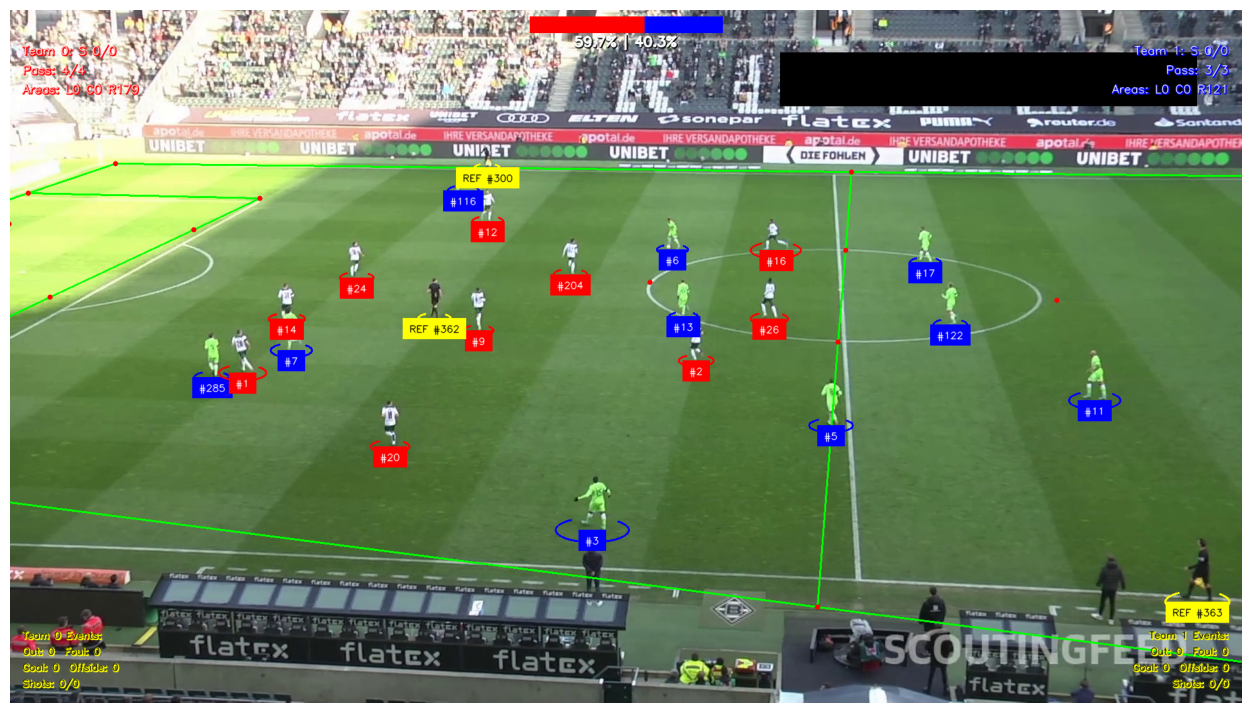

In [37]:
# عرض الإطار الأخير
if 'annotated_frame' in locals() and annotated_frame is not None:
    sv.plot_image(annotated_frame, size=(16, 9))

In [38]:
from PIL import Image
import numpy as np

if 'annotated_frame' in locals() and annotated_frame is not None:
    # تأكد أن الفريم هو مصفوفة NumPy بصيغة uint8
    image = Image.fromarray(annotated_frame)
    
    # حفظ الصورة
    image.save("annotated_frame.png")
    print("Last frame is saved with name --> annotated_frame.png")

Last frame is saved with name --> annotated_frame.png
